In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the brute-force LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780     # fixed: not searched
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    h_stack, idx_ok = [], []
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
                T=T, dt=dt,
            ))
            h_stack.append(h_temp)
            idx_ok.append(i)
        except Exception:
            pass
    if h_stack:
        h_batch = gwf.xp.stack(h_stack, axis=0)  # (b, n_chan, N)
        snr = gwf.SNR_semicoherent_batch(loglike_obj.signal, h_batch, N_seg=N_SEGS, phase_max=True)
        for k, i in enumerate(idx_ok):
            out[i] = float(snr[k])
    return out


# Broad priors — same bounds as run_lhs_noise_sc_brute.py. xI0 (only 1.0 is
# valid for the waveform model) and Phi_theta0 are held fixed (not
# searched); sky/spin polar angles sampled uniform in cosine.
LOGM1_LIM = [5.6,  6.4]
LOGM2_LIM = [1.7,  2.3]
A_LIM     = [0.3,  0.999]
P0_LIM    = [13.5,  16.5]
E0_LIM    = [0.6,  0.9]
DIST_LIM  = [3,  5]
COSQS_LIM = [-1.0, 1.0]
PHIS_LIM  = [0.0,  2 * np.pi]
COSQK_LIM = [-1.0, 1.0]
PHIK_LIM  = [0.0,  2 * np.pi]
PHIPHI0_LIM = [0.0, 2 * np.pi]
PHIR0_LIM   = [0.0, 2 * np.pi]


def prior_transform(u):
    t = np.zeros_like(u)
    t[:, 0]  = (LOGM1_LIM[1] - LOGM1_LIM[0]) * u[:, 0] + LOGM1_LIM[0]
    t[:, 1]  = (LOGM2_LIM[1] - LOGM2_LIM[0]) * u[:, 1] + LOGM2_LIM[0]
    t[:, 2]  = (A_LIM[1] - A_LIM[0]) * u[:, 2] + A_LIM[0]
    t[:, 3]  = (P0_LIM[1] - P0_LIM[0]) * u[:, 3] + P0_LIM[0]
    t[:, 4]  = (E0_LIM[1] - E0_LIM[0]) * u[:, 4] + E0_LIM[0]
    t[:, 5]  = (DIST_LIM[1] - DIST_LIM[0]) * u[:, 5] + DIST_LIM[0]
    t[:, 6]  = (COSQS_LIM[1] - COSQS_LIM[0]) * u[:, 6] + COSQS_LIM[0]
    t[:, 7]  = (PHIS_LIM[1] - PHIS_LIM[0]) * u[:, 7] + PHIS_LIM[0]
    t[:, 8]  = (COSQK_LIM[1] - COSQK_LIM[0]) * u[:, 8] + COSQK_LIM[0]
    t[:, 9]  = (PHIK_LIM[1] - PHIK_LIM[0]) * u[:, 9] + PHIK_LIM[0]
    t[:, 10] = (PHIPHI0_LIM[1] - PHIPHI0_LIM[0]) * u[:, 10] + PHIPHI0_LIM[0]
    t[:, 11] = (PHIR0_LIM[1] - PHIR0_LIM[0]) * u[:, 11] + PHIR0_LIM[0]
    return t


def inverse_prior_transform(params):
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0]  = (params[:, 0] - LOGM1_LIM[0]) / (LOGM1_LIM[1] - LOGM1_LIM[0])
    u[:, 1]  = (params[:, 1] - LOGM2_LIM[0]) / (LOGM2_LIM[1] - LOGM2_LIM[0])
    u[:, 2]  = (params[:, 2] - A_LIM[0]) / (A_LIM[1] - A_LIM[0])
    u[:, 3]  = (params[:, 3] - P0_LIM[0]) / (P0_LIM[1] - P0_LIM[0])
    u[:, 4]  = (params[:, 4] - E0_LIM[0]) / (E0_LIM[1] - E0_LIM[0])
    u[:, 5]  = (params[:, 5] - DIST_LIM[0]) / (DIST_LIM[1] - DIST_LIM[0])
    u[:, 6]  = (params[:, 6] - COSQS_LIM[0]) / (COSQS_LIM[1] - COSQS_LIM[0])
    u[:, 7]  = (params[:, 7] - PHIS_LIM[0]) / (PHIS_LIM[1] - PHIS_LIM[0])
    u[:, 8]  = (params[:, 8] - COSQK_LIM[0]) / (COSQK_LIM[1] - COSQK_LIM[0])
    u[:, 9]  = (params[:, 9] - PHIK_LIM[0]) / (PHIK_LIM[1] - PHIK_LIM[0])
    u[:, 10] = (params[:, 10] - PHIPHI0_LIM[0]) / (PHIPHI0_LIM[1] - PHIPHI0_LIM[0])
    u[:, 11] = (params[:, 11] - PHIR0_LIM[0]) / (PHIR0_LIM[1] - PHIR0_LIM[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage1_merge_brute_smol_dev/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl', 
                                    prior_transform=prior_transform, 
                                    log_density_func=log_density)
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.now_covariances

[array([[ 1.60141434e-04,  4.47873645e-05,  5.12744891e-04,
         -7.86243408e-04, -4.96262882e-05,  7.24756786e-04,
          5.85802773e-05, -2.40717622e-05,  9.79863277e-05,
         -1.26863446e-05,  2.13082609e-04, -7.22810515e-05],
        [ 4.47873645e-05,  1.56685944e-05,  1.42592208e-04,
         -2.16563175e-04, -1.54673011e-05,  2.53858600e-04,
          1.39411668e-05, -6.52942492e-06,  2.92483776e-07,
         -1.56188240e-05,  2.39766243e-06,  1.36495089e-05],
        [ 5.12744891e-04,  1.42592208e-04,  1.65432696e-03,
         -2.53631412e-03, -1.58657507e-04,  2.30477731e-03,
          1.81186453e-04, -7.69692131e-05,  3.62792891e-04,
         -3.81436272e-05,  7.60423333e-04, -2.69236704e-04],
        [-7.86243408e-04, -2.16563175e-04, -2.53631412e-03,
          3.89653969e-03,  2.43310018e-04, -3.50672598e-03,
         -2.90225947e-04,  1.19979208e-04, -5.88366520e-04,
          6.84648321e-05, -1.21680846e-03,  4.47551079e-04],
        [-4.96262882e-05, -1.5467301

In [5]:
len(sampler.now_covariances)

4

In [6]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.83888233,  1.99508088,  0.53260102, 15.49428954,  0.74277037,
         3.42173166, -0.81693943,  6.20612958,  0.68383861,  3.40334945,
         2.13301005,  1.06781285]])

In [7]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.82623234,  1.99265078,  0.49880019, 15.72571002,  0.74412015,
         3.68020276, -0.74114897,  0.46854545,  0.74075308,  3.39688968,
         1.68448185,  0.29917063]])

In [8]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[ 5.78440399,  1.98500092,  0.3723962 , 16.54647779,  0.74910471,
         3.27255197,  0.813273  ,  3.77700384,  0.28032554,  3.55071004,
         0.28182991,  2.63750765]])

In [9]:
maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))
maxld_pt4

array([[ 5.80141172,  1.98700808,  0.42580355, 16.18796172,  0.74719703,
         3.75845764, -0.26874332,  0.12167583, -0.05931011,  3.04822372,
         5.00952448,  6.2049413 ]])

In [10]:
log_density(maxld_pt1), log_density(maxld_pt2), log_density(maxld_pt3), log_density(maxld_pt4)

(array([90.70827254]),
 array([78.93876269]),
 array([62.11929006]),
 array([72.31601247]))

In [11]:
log_density([param_true])

array([100.65186542])

In [12]:
param_ranges = [(LOGM1_LIM[0], LOGM1_LIM[1]),
                (LOGM2_LIM[0], LOGM2_LIM[1]),
                (A_LIM[0], A_LIM[1]),
                (P0_LIM[0], P0_LIM[1]),
                (E0_LIM[0], E0_LIM[1]),
                (DIST_LIM[0], DIST_LIM[1]),
                (COSQS_LIM[0], COSQS_LIM[1]),
                (PHIS_LIM[0], PHIS_LIM[1]),
                (COSQK_LIM[0], COSQK_LIM[1]),
                (PHIK_LIM[0], PHIK_LIM[1]),
                (PHIPHI0_LIM[0], PHIPHI0_LIM[1]),
                (PHIR0_LIM[0], PHIR0_LIM[1])]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 4.755,
 0.8306067129371271,
 3.5808,
 0.38950706335529234,
 3.8495,
 3.194,
 0.6038]

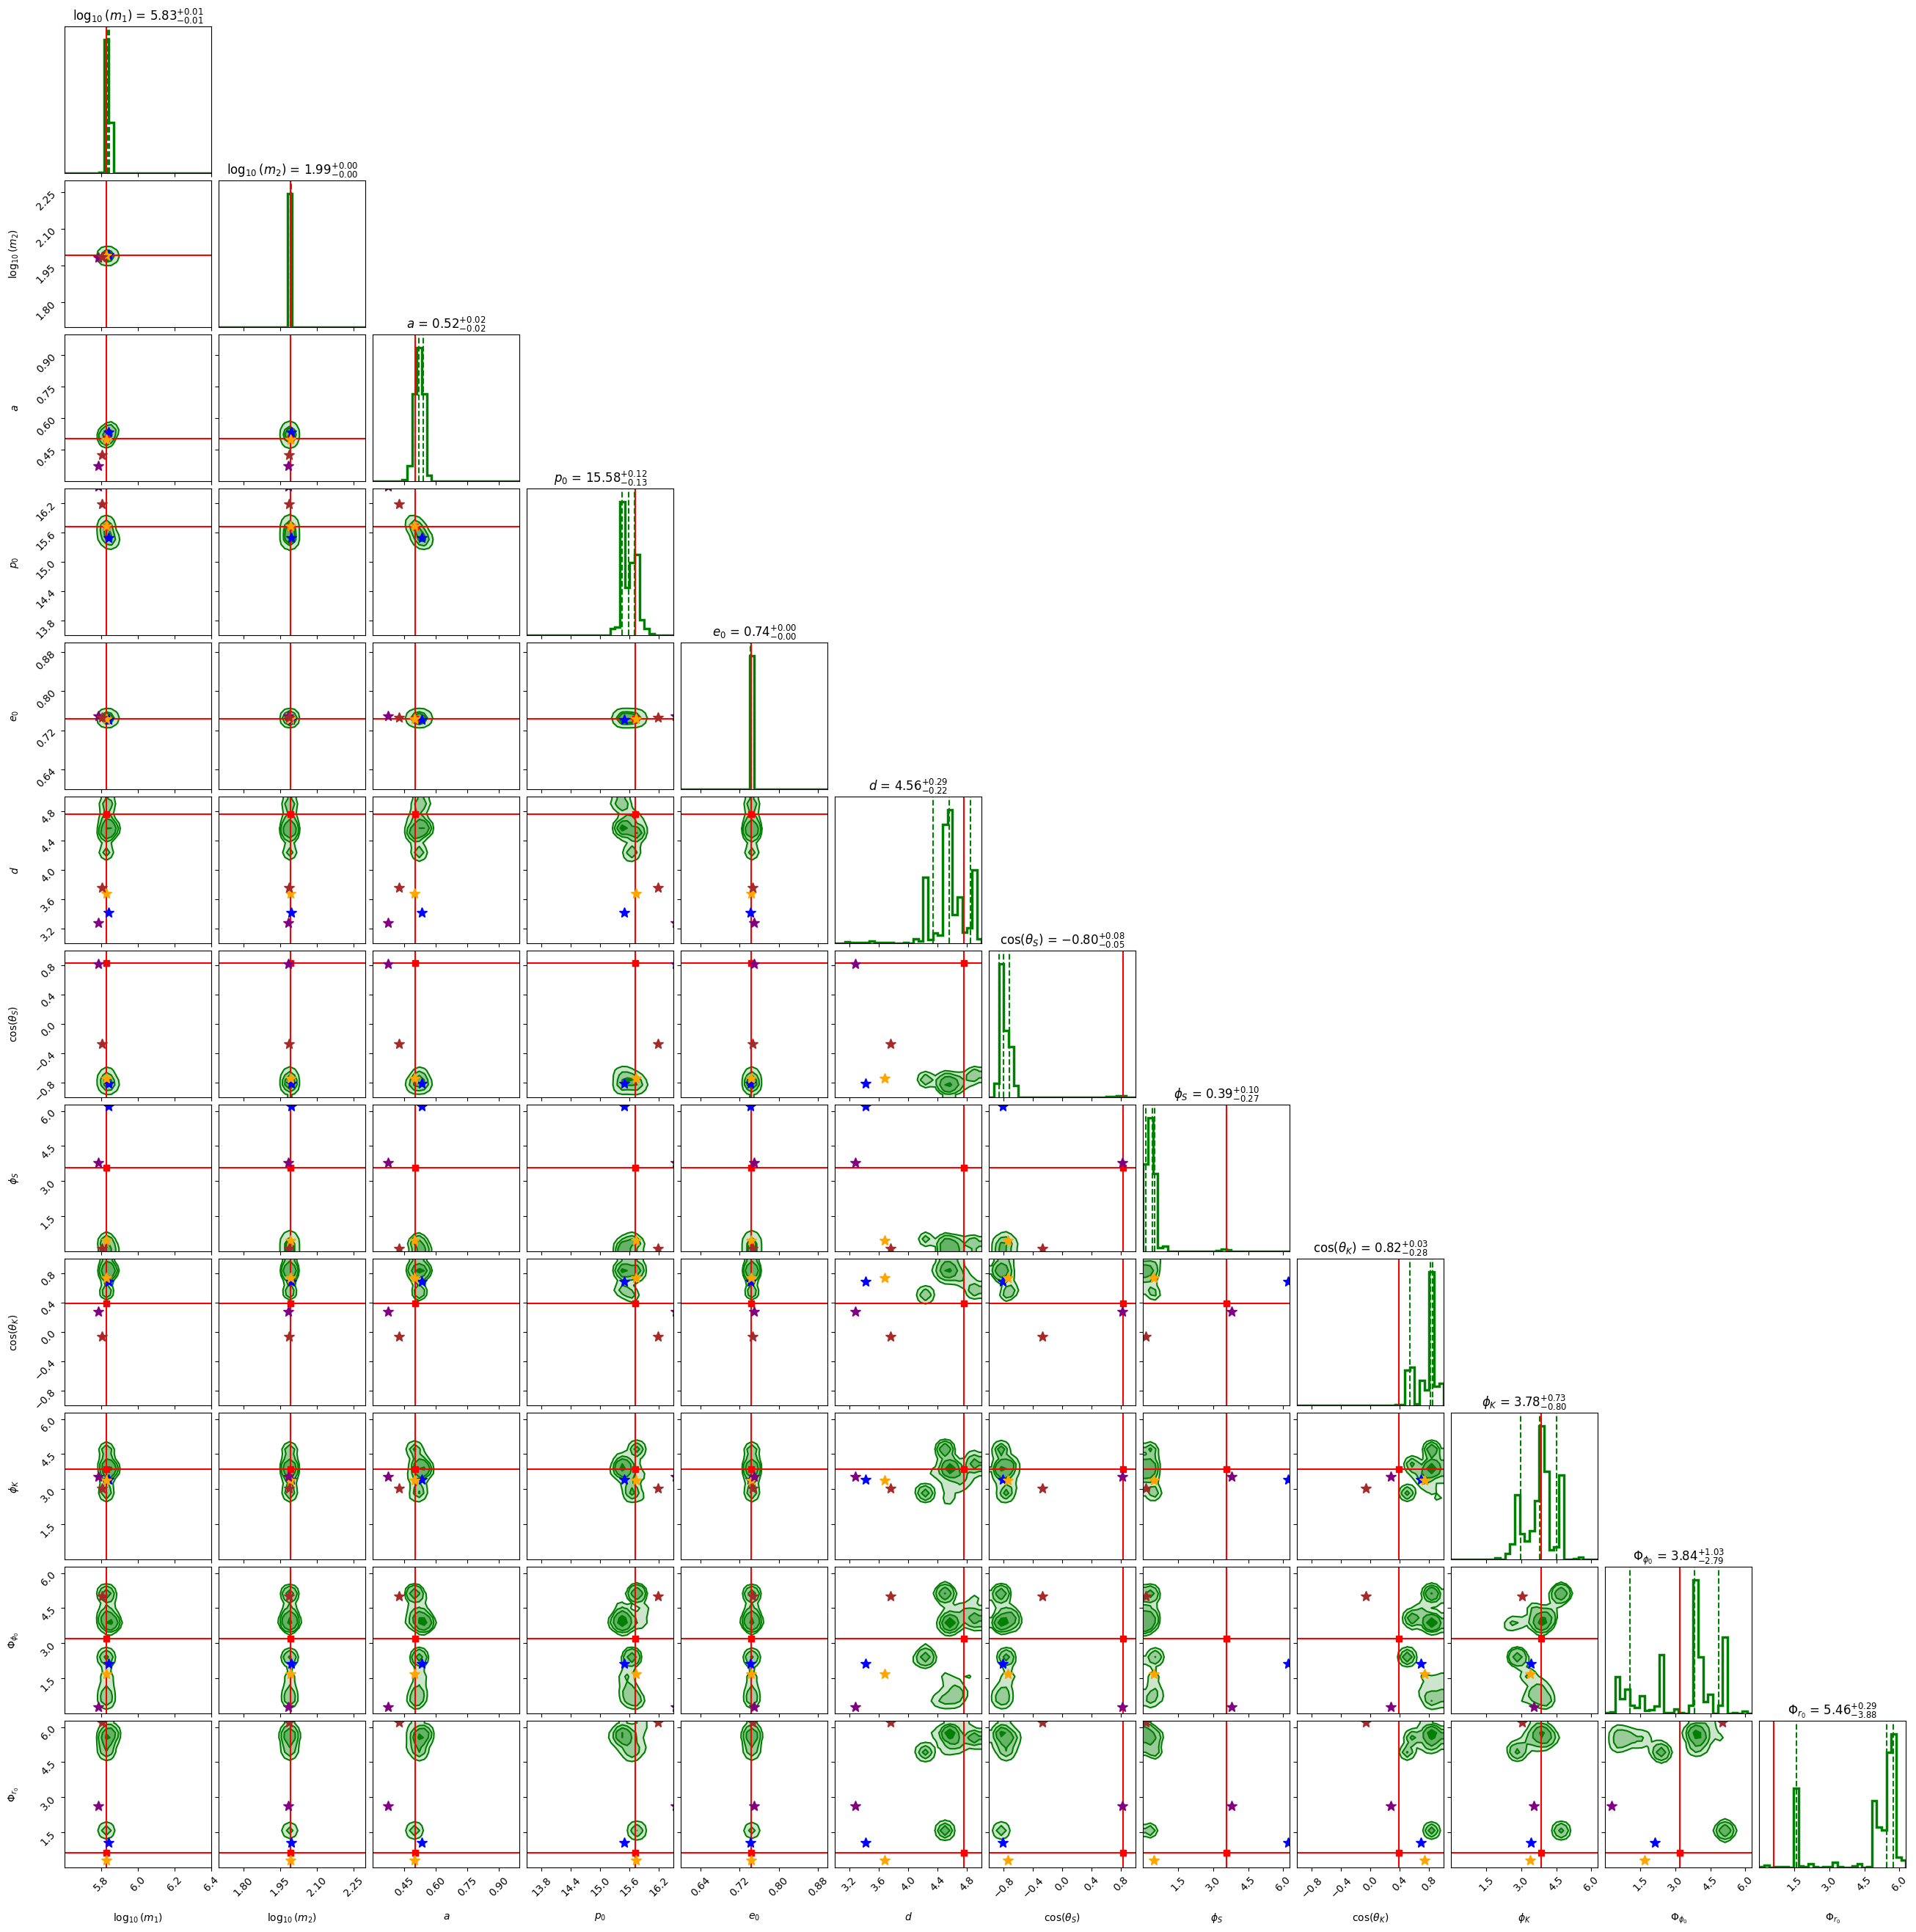

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$d$', r'$\cos(\theta_S)$', r'$\phi_S$', r'$\cos(\theta_K)$', r'$\phi_K$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


corner.overplot_points(fig, maxld_pt2.reshape(1, -1),
                       color='orange', marker='*', ms=10,
                       reverse=False)   

corner.overplot_points(fig, maxld_pt3.reshape(1, -1),
                       color='purple', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1),
                       color='brown', marker='*', ms=10,
                       reverse=False)

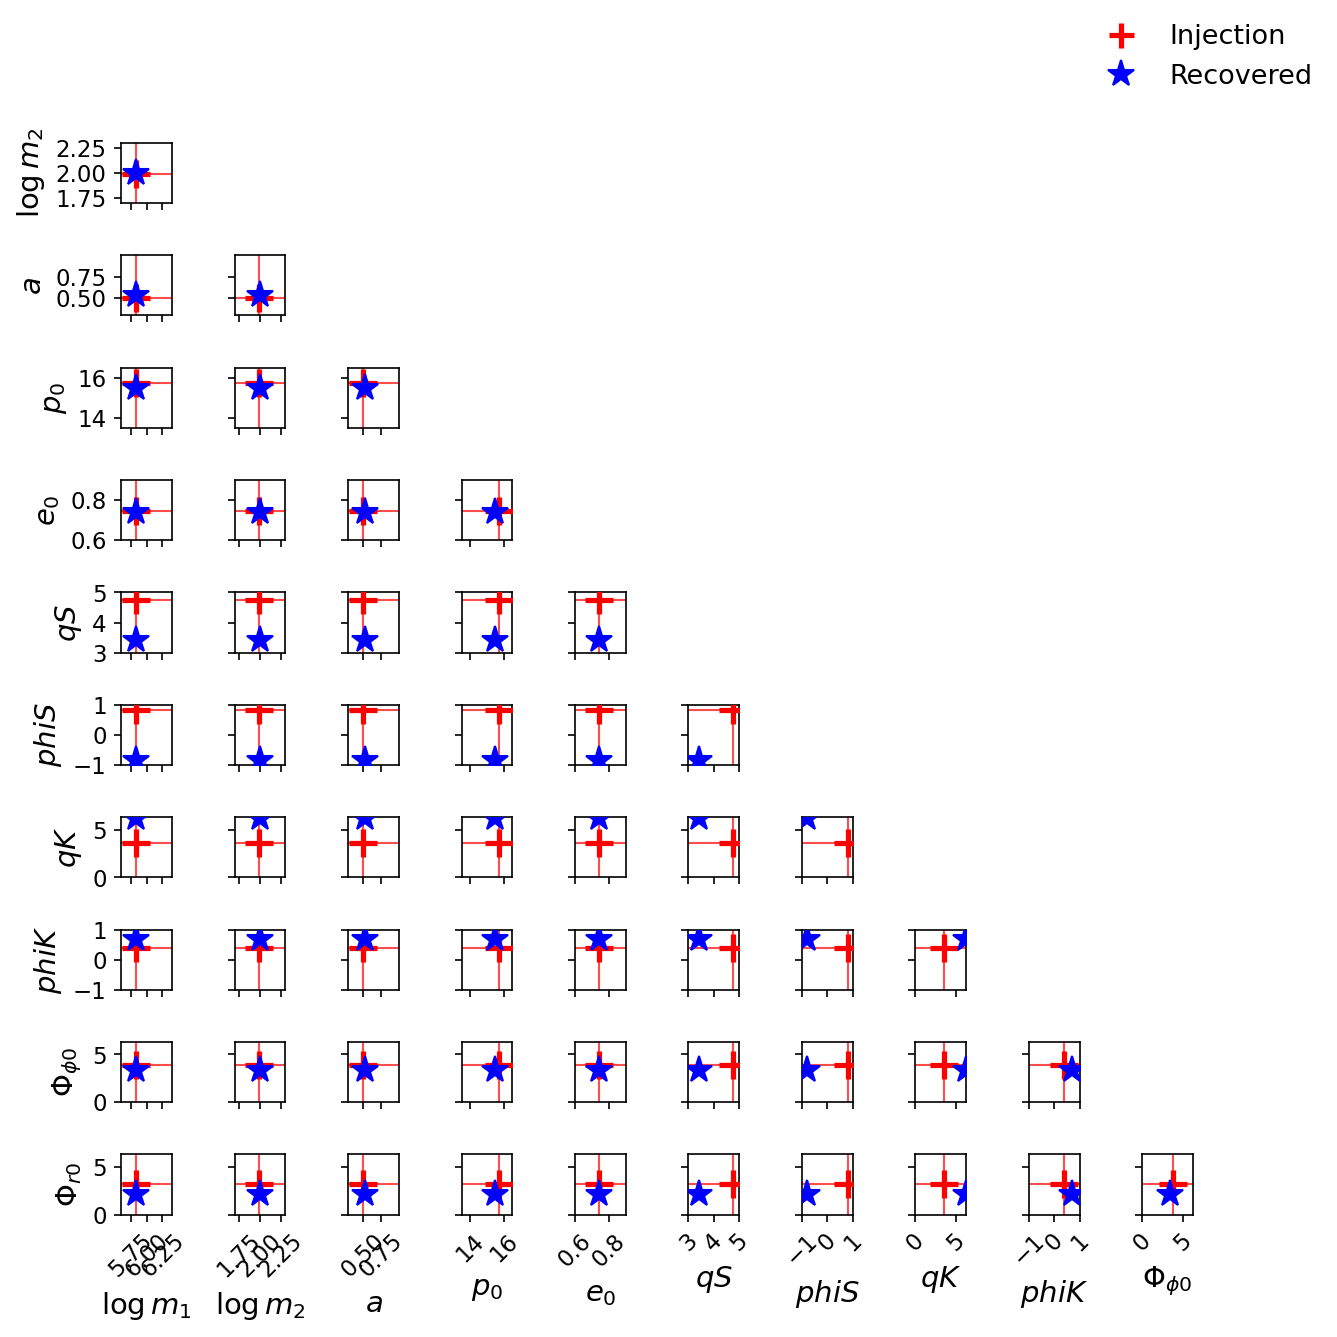

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$', r'$qK$', r'$phiK$', r'$\Phi_{\phi0}$', r'$\Phi_{r0}$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()


# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [16]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.83888233,  1.99508088,  0.53260102, 15.49428954,  0.74277037,
         3.42173166, -0.81693943,  6.20612958,  0.68383861,  3.40334945,
         2.13301005,  1.06781285]])

In [17]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [18]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


OutOfMemoryError: Out of memory allocating 61,222,004,736 bytes (allocated so far: 132,622,945,792 bytes).

In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


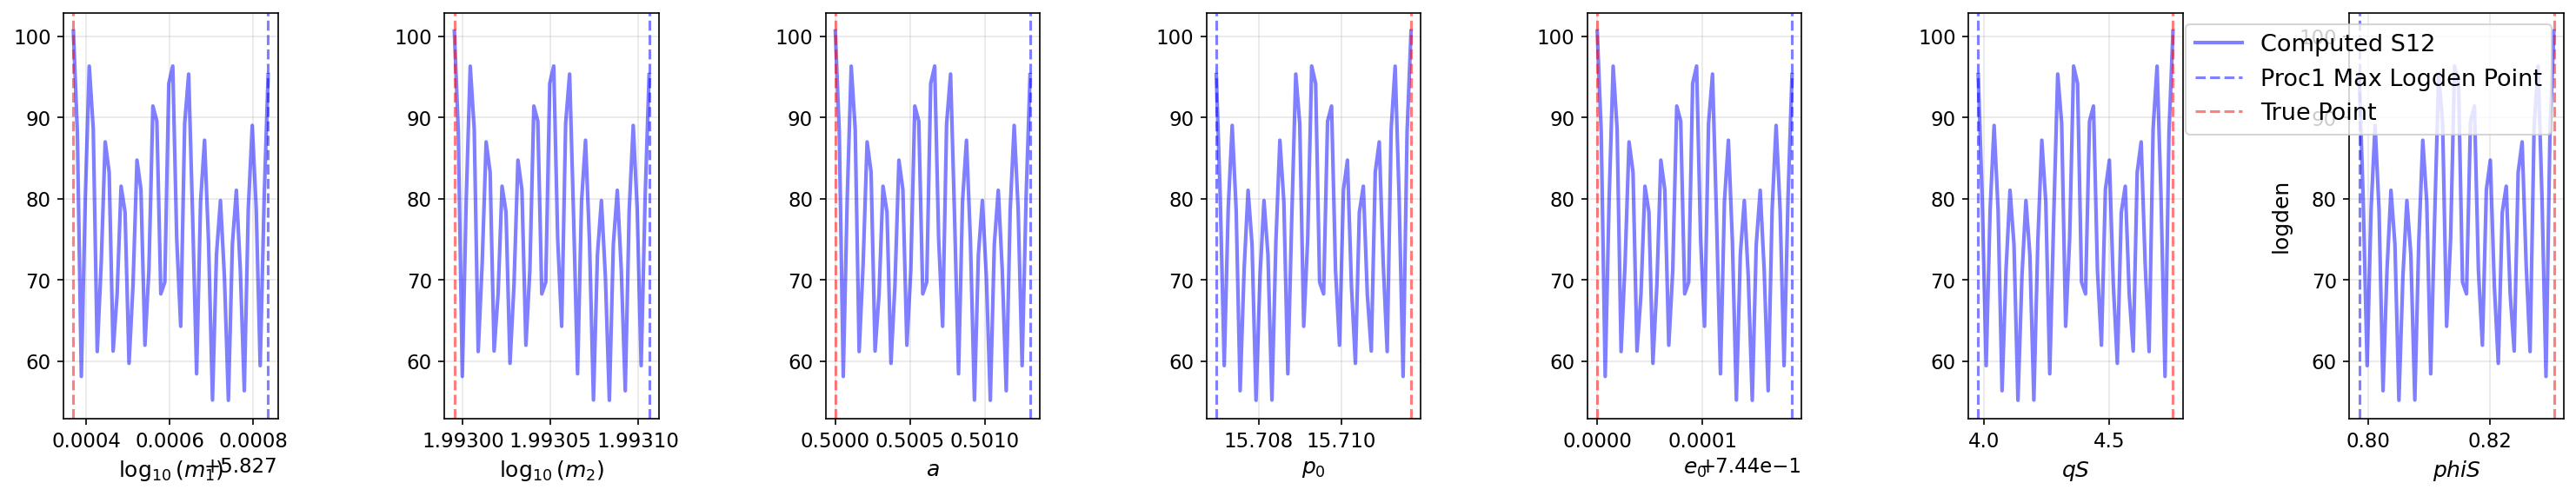

In [ ]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [18]:
def log_density_safe(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            cos_qS_i = np.clip(cos_qS_i, -1.0, 1.0)
            cos_qK_i = np.clip(cos_qK_i, -1.0, 1.0)
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out

In [19]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [20]:
i = 0  # logm1

n_dims = len(direction)
t_lo_candidates = []
t_hi_candidates = []
for d in range(n_dims):
    if direction[d] == 0:
        continue
    lo, hi = prior_lo[d], prior_hi[d]
    t_a = (lo - start[d]) / direction[d]
    t_b = (hi - start[d]) / direction[d]
    t_lo_candidates.append(min(t_a, t_b))
    t_hi_candidates.append(max(t_a, t_b))

t_lo_logm1 = max(t_lo_candidates)
t_hi_logm1 = min(t_hi_candidates)

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

# keep only inserted points that fall inside the now-tighter valid range
t_values_logm1 = np.sort(np.concatenate([
    t_values_logm1,
    [t for t in (t_true, t_secondary) if t_lo_logm1 <= t <= t_hi_logm1]
]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]

In [21]:
logden_tm = log_density_safe(line_points_logm1.T)


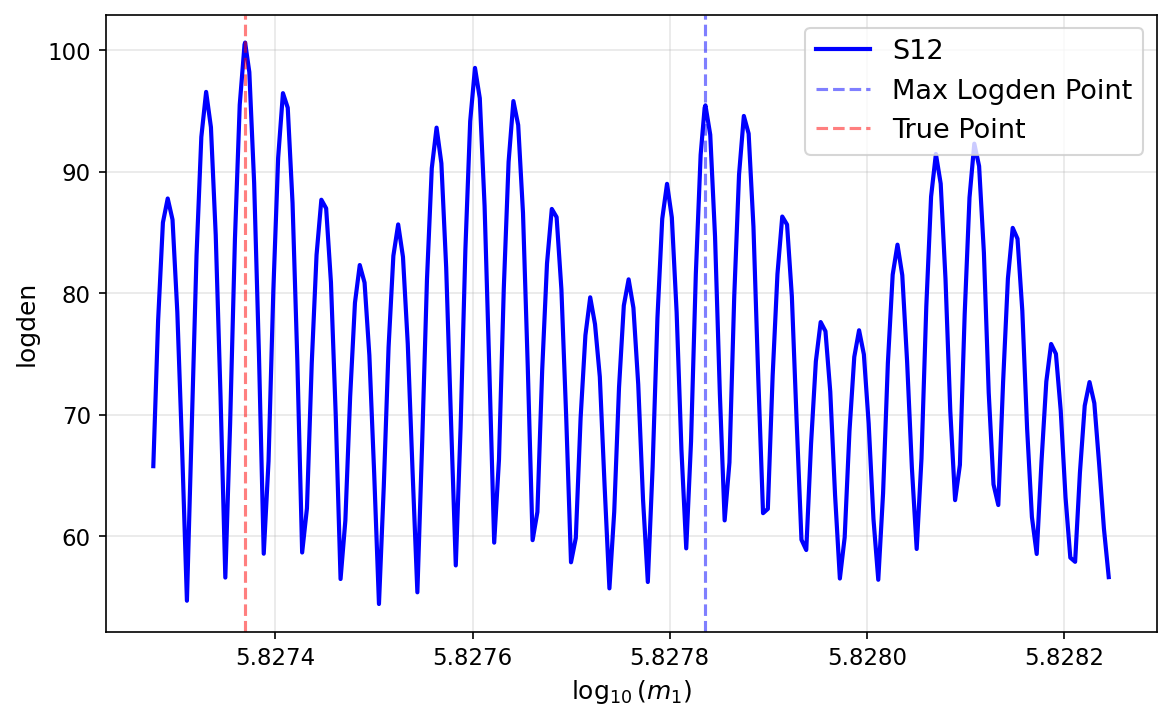

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S12')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [24]:
def scan_1d(idx, lo, hi, n_points=200, base=None):
    base = np.array(param_true if base is None else base)
    vals = np.linspace(lo, hi, n_points)
    pts = np.tile(base, (n_points, 1))
    pts[:, idx] = vals
    return vals, log_density_safe(pts)

vals_phir0, logden_phir0     = scan_1d(11, PHIR0_LIM[0], PHIR0_LIM[1])
vals_phiphi0, logden_phiphi0 = scan_1d(10, PHIPHI0_LIM[0], PHIPHI0_LIM[1])

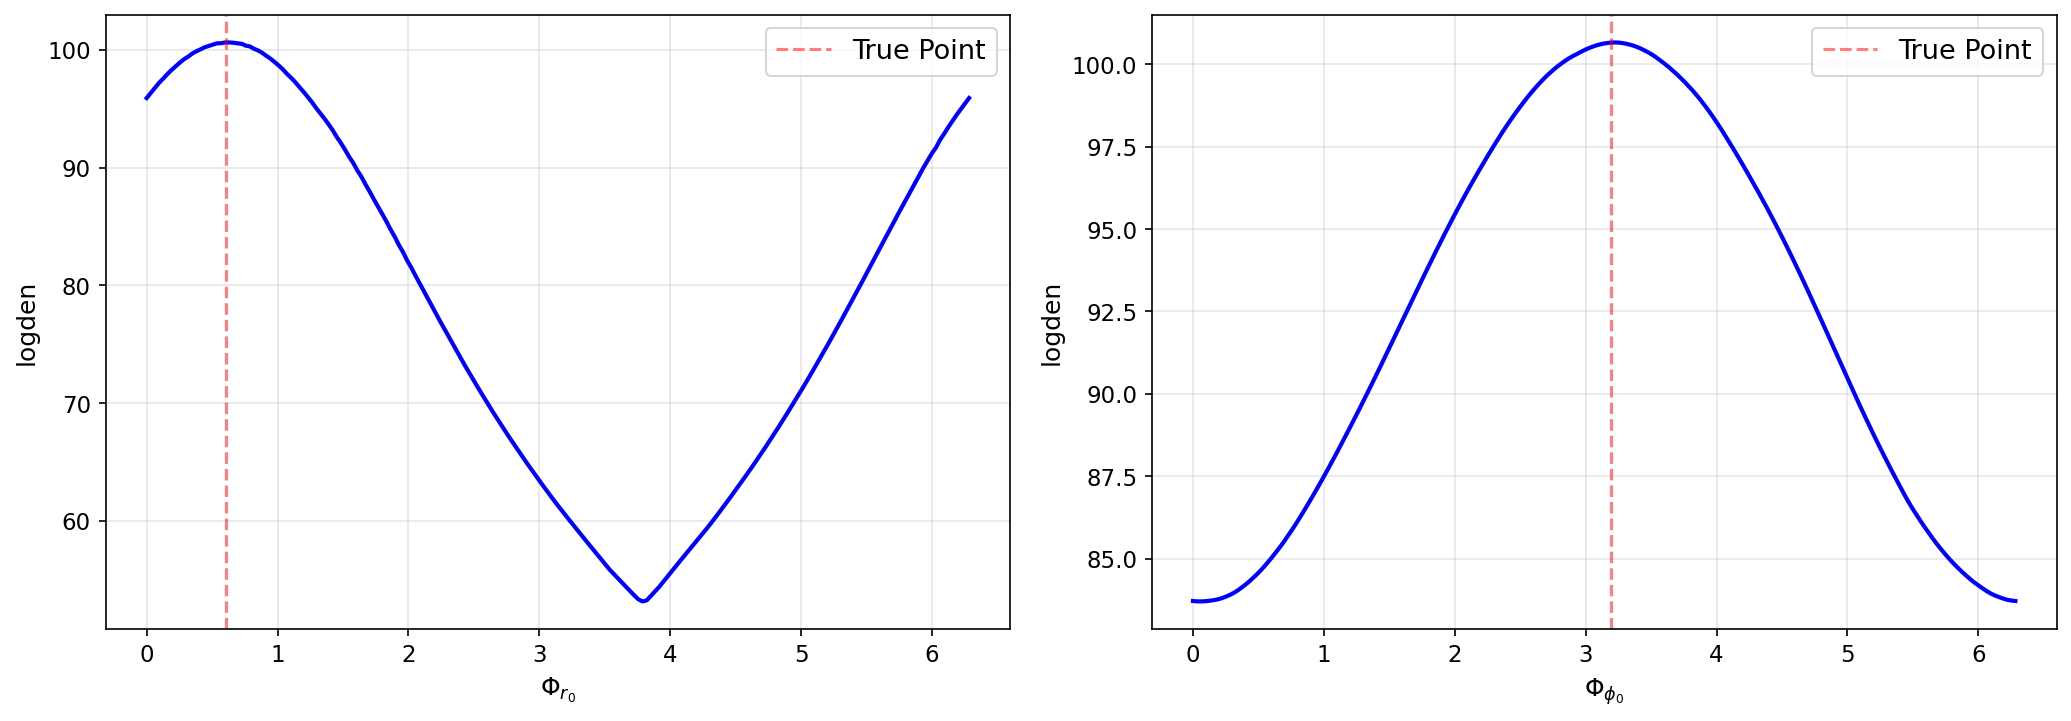

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(vals_phir0, logden_phir0, '-', color='blue', linewidth=2)
axs[0].axvline(param_true[11], color='red', linestyle='--', alpha=0.5, label='True Point')
axs[0].set_xlabel(r'$\Phi_{r_0}$', fontsize=12)
axs[0].set_ylabel('logden', fontsize=12)
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(vals_phiphi0, logden_phiphi0, '-', color='blue', linewidth=2)
axs[1].axvline(param_true[10], color='red', linestyle='--', alpha=0.5, label='True Point')
axs[1].set_xlabel(r'$\Phi_{\phi_0}$', fontsize=12)
axs[1].set_ylabel('logden', fontsize=12)
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()